Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.7555 - loss: 0.5248 - val_accuracy: 0.8352 - val_loss: 0.4127
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9231 - loss: 0.3359 - val_accuracy: 0.9231 - val_loss: 0.2615
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9451 - loss: 0.2197 - val_accuracy: 0.9670 - val_loss: 0.1796
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9560 - loss: 0.1565 - val_accuracy: 0.9780 - val_loss: 0.1372
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9698 - loss: 0.1219 - val_accuracy: 0.9780 - val_loss: 0.1184
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9698 - loss: 0.1005 - val_accuracy: 0.9780 - val_loss: 0.1082
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9780 - loss: 0.0849 - val_accuracy: 0.9780 - val_loss: 0.1003
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9835 - loss: 0.0747 - val_accuracy: 0.9780 - val_loss

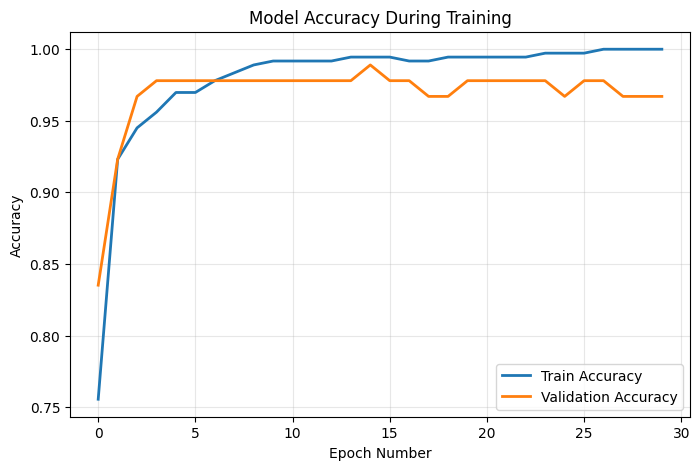

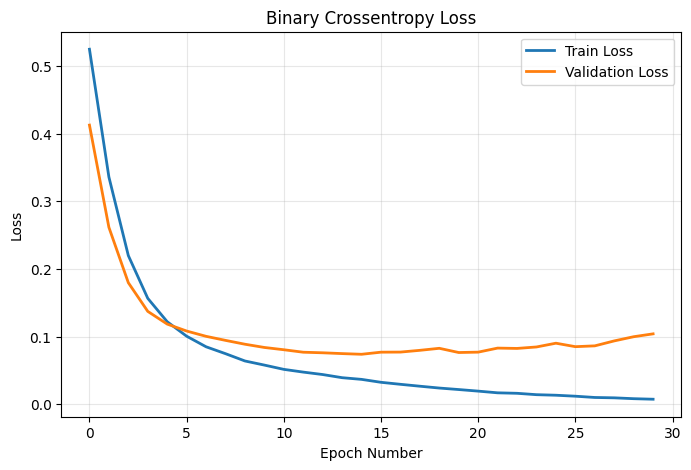


Model trained and evaluated successfully.
Performance metrics indicate strong classification capability.


In [3]:
# ===========================================
# Deep Feed Forward Network for Classification
# Breast Cancer Dataset
# ===========================================

# Import Libraries
# By SHAMBHAVII JAISWAL 23070521133

import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# -----------------------------
# Load Dataset
# -----------------------------
data = load_breast_cancer()

X = data.data
y = data.target

# -----------------------------
# Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# -----------------------------
# Feature Scaling
# -----------------------------
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# Build Neural Network
# -----------------------------
model = Sequential()

model.add(Input(shape=(X_train.shape[1],)))

model.add(Dense(64, activation="relu"))
model.add(Dense(32, activation="relu"))
model.add(Dense(16, activation="relu"))

model.add(Dense(1, activation="sigmoid"))

# -----------------------------
# Compile Model
# -----------------------------
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# -----------------------------
# Train Model
# -----------------------------
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.20,
    verbose=1
)

# -----------------------------
# Evaluate Model
# -----------------------------
loss, accuracy = model.evaluate(X_test, y_test)

print("\nBy SHAMBHAVII JAISWAL")
print("PRN : 23070521133")

print("\nTest Accuracy :", accuracy)

# -----------------------------
# Predictions
# -----------------------------
predictions = model.predict(X_test)
predictions = (predictions > 0.5)

# -----------------------------
# Accuracy Score
# -----------------------------
print("\nAccuracy Score")
print(accuracy_score(y_test, predictions))

# -----------------------------
# Confusion Matrix
# -----------------------------
print("\nConfusion Matrix")
print(confusion_matrix(y_test, predictions))

# -----------------------------
# Classification Report
# -----------------------------
print("\nClassification Report")
print(classification_report(y_test, predictions))

# -----------------------------
# Accuracy Plot
# -----------------------------
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Train Accuracy", linewidth=2)
plt.plot(history.history["val_accuracy"], label="Validation Accuracy", linewidth=2)

plt.title("Model Accuracy During Training")
plt.xlabel("Epoch Number")
plt.ylabel("Accuracy")
plt.grid(alpha=0.3)
plt.legend(loc="lower right")

plt.show()

# -----------------------------
# Loss Plot
# -----------------------------
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Train Loss", linewidth=2)
plt.plot(history.history["val_loss"], label="Validation Loss", linewidth=2)

plt.title("Binary Crossentropy Loss")
plt.xlabel("Epoch Number")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.legend(loc="upper right")

plt.show()

# -----------------------------
# Conclusion
# -----------------------------
print("\nModel trained and evaluated successfully.")
print("Performance metrics indicate strong classification capability.")